In [107]:
#Aufgabe 1.1.
%matplotlib inline
import numpy as np
import pandas as pd

listings = pd.read_csv("Daten/listings_berlin.csv")

print(f"Anzahl Zeilen: {len(listings)} \nAnzahl Spalten: {len(listings.columns)}")

Anzahl_NAs = listings.isna().sum()
Anteil_NAs = listings.isna().mean().map("{:.2%}".format)

listings_1_1 = pd.DataFrame({"Anzahl NAs":Anzahl_NAs, "Anteil NAs":Anteil_NAs})
listings_1_1.head(20)

Anzahl Zeilen: 14274 
Anzahl Spalten: 20


,Anzahl NAs,Anteil NAs
price,5010,35.10%
neighbourhood_cleansed,0,0.00%
latitude,0,0.00%
longitude,0,0.00%
room_type,0,0.00%
bedrooms,2024,14.18%
bathrooms_text,16,0.11%
accommodates,0,0.00%
amenities,0,0.00%
host_since,14,0.10%


In [108]:
#Aufagbe 1.2
#Die Tabelle aus Aufgabe 1_1 wird nach den Werten in Spalte "Anteil NAs" in "descending"-order sortiert. 
#Es werden nur die obersten drei Werte angezeigt. 
print("Die folgenden drei Werte haben die höchste Rate an fehlenden Werten:")
listings_1_1.sort_values("Anteil NAs", ascending=False).head(3)


Die folgenden drei Werte haben die höchste Rate an fehlenden Werten:


,Anzahl NAs,Anteil NAs
host_response_rate,5018,35.15%
price,5010,35.10%
reviews_per_month,3314,23.22%


placeholder für den Rest von Aufgabe 1_2

In [109]:
#Aufgabe 1_3
#Funktion wird definiert, um string-Einträge in numbers-Einträge umzuwandeln.
def clean_price(price_str):
    """Diese Funktion wandelt string in numeric um."""

    if pd.isna(price_str):
        return np.nan
    price_str_clean = str(price_str).replace("$", "").replace(',', '')
    try:
        price_number = float(price_str_clean)
        if price_number > 0:
            return price_number
        else:
            return np.nan
    except ValueError:
        return np.nan
#Nun wenden wir es auf die gesamte Spalte "price" an.
listings_1_3 = listings.copy()
listings_1_3["price"] = listings_1_3["price"].apply(clean_price)
listings_1_3["price"].describe().loc[['min', '50%', 'mean', 'max']]

min         5.000000
50%       104.000000
mean      201.240393
max     50000.000000
Name: price, dtype: float64

In [110]:
#Aufgabe 1.4
listings_1_4 = listings_1_3.copy()
#Zunächst schauen wir, welche einzigartigen Einträge es gibt mit:
#listings_1_4["bathrooms_text"].unique()

#Wir wollen nun die Textdarstellung der Bädersituationen umwandeln in eine numerische Form.
#Regel 1: Die Spezifikation eines "Privaten" Bades ist redundant.
#Regel 2: Die Information eines "Shared" Bades wird durch eine neue boolean-Spalte "Shared_bath_status" erhalten.
#Regel 3: Ein "Half"-Bad gilt als 0.5 Bad.

#Umsetzung Regel 2:
listings_1_4["Shared_bath_status"] = listings_1_4["bathrooms_text"].str.contains("shared", case=False)
#Umsetzung Regel 3:
listings_1_4["bathrooms_text"] = listings_1_4["bathrooms_text"].str.replace("Half-Bath", "0.5", case=False)
#Umsetzung der Umwandlung zu Numerisch unter Beachtung der Regel 1:
listings_1_4["bathrooms_text"] = pd.to_numeric(
    listings_1_4["bathrooms_text"].str.replace({
    "baths": "",
    "shared": "",
    "private": "",
    "bath": "",
    " ": ""
    }, case=False)
)
listings_1_4[["bathrooms_text", "Shared_bath_status"]].head()

,bathrooms_text,Shared_bath_status
0,1.0,False
1,2.5,False
2,1.0,False
3,1.0,False
4,1.0,False


In [111]:
#Aufgabe 1.5
listings_1_5 = listings_1_4.copy()
#Zunächst konvertieren wir "t" zu True und "f" zu False, und NaN auch zu False, da der Standard False ist.
listings_1_5["instant_bookable"] = listings_1_5["instant_bookable"] == "t"
listings_1_5["host_is_superhost"] = listings_1_5["host_is_superhost"] == "t"
#Wir kreieren die Spalte "host_tenure_years" und verwerfen die Spalte "host_since", da die Informationen redundant werden.
#Datenformat ist egal, da nur das Jahr abgefragt wird.
listings_1_5["host_tenure_years"] = 2025 - pd.to_datetime(listings_1_5["host_since"]).dt.year
#Wir droppen die Spalte "host_since".
listings_1_5 = listings_1_5.drop(columns="host_since")
listings_1_5.columns

Index(['price', 'neighbourhood_cleansed', 'latitude', 'longitude', 'room_type',
       'bedrooms', 'bathrooms_text', 'accommodates', 'amenities',
       'host_is_superhost', 'host_listings_count', 'host_response_rate',
       'review_scores_rating', 'review_scores_cleanliness',
       'number_of_reviews', 'reviews_per_month', 'minimum_nights',
       'availability_365', 'instant_bookable', 'Shared_bath_status',
       'host_tenure_years'],
      dtype='str')

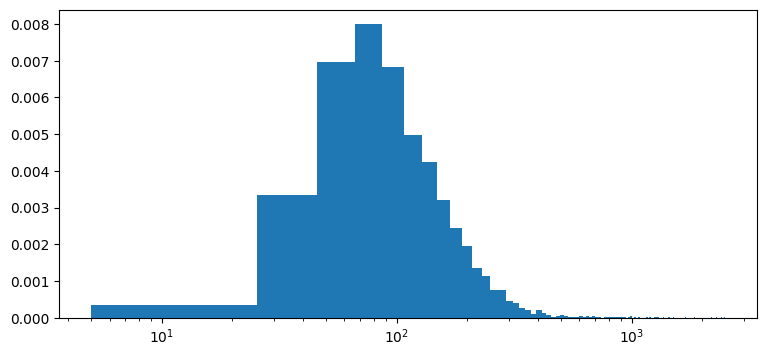

3214.253030361427


In [112]:
#Aufgabe 1.6
import matplotlib.pyplot as plt
#prices = listings_1_5["price"]

log_prices = np.log(listings_1_5["price"])

mu_log = np.mean(log_prices)
sigma_log = np.std(log_prices)

upper_bound = np.exp(mu_log + 5 * sigma_log)
fig = plt.figure(figsize=(9, 4))
plt.hist(
    listings_1_5.loc[listings_1_5["price"] <= upper_bound]["price"],
    log= False, bins = 122,
    density=True,
    label='empirical density'
) # plotting a histogram 
plt.xscale("log")
plt.show()
print(upper_bound)

In [113]:
#Unterbrechung in x-Achse machen